In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
from interpret import show

In [2]:
df_d07_v1 = pd.read_csv("Input/D07_V1.csv")
df_d07_v1.head()


,1_age,2_workclass,3_final_weight,4_education,5_education_num,6_marital_status,7_occupation,8_relationship,9_race,10_sex,11_capital_gain,12_capital_loss,13_hours_per_week,14_native_country,15_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [3]:
y = df_d07_v1['15_income']
X = df_d07_v1.drop(columns=['15_income'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

ebm = ExplainableBoostingClassifier(random_state=42)

ebm.fit(X_train, y_train)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


              precision    recall  f1-score   support

           0       0.90      0.95      0.92     11147
           1       0.79      0.65      0.71      3506

    accuracy                           0.88     14653
   macro avg       0.84      0.80      0.82     14653
weighted avg       0.87      0.88      0.87     14653



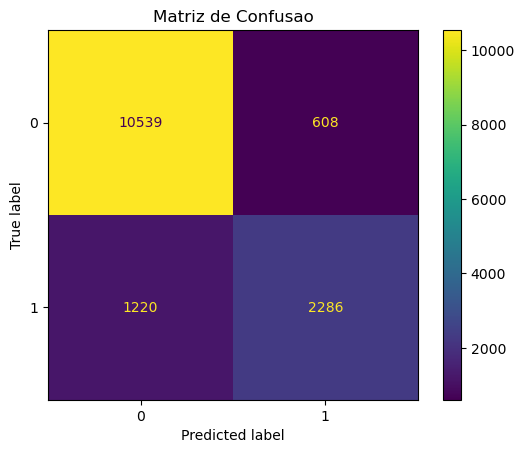

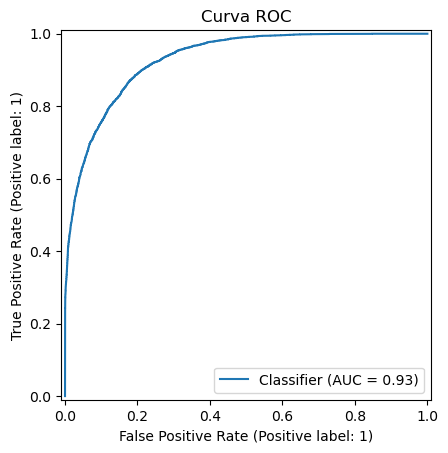

In [4]:
# 1. Gerar previsões nos dados de teste
y_pred = ebm.predict(X_test)
y_pred_proba = ebm.predict_proba(X_test)[:, 1]

# 2. Relatório textual com precisão, recall e f1-score
print(classification_report(y_test, y_pred))

# 3. Plotagem da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matriz de Confusao")
plt.show()

# 4. Plotagem da curva ROC
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title("Curva ROC")
plt.show()

In [5]:
ebm_global = ebm.explain_global(name='Importancia das Variaveis')
show(ebm_global)

ebm_local = ebm.explain_local(X_test[:5], y_test[:5], name='Previsoes Individuais')
show(ebm_local)

<!-- http://127.0.0.1:7001/134768595202448/ -->

<!-- http://127.0.0.1:7001/134768472573168/ -->